# Analiza danych tekstowych, porównanie technik obróbki tekstu w kontekście klasyfikacji

Wykonanie analizy oraz stworzenie modeli klasyfikacji tekstu w kontekście analizy sentymentu na podstawie danych SPAM ([Link do zbioru danych w serwisie Kaggle](https://www.kaggle.com/datasets/team-ai/spam-text-message-classification)). Wykorzystanie różnych technik przetwarzania tekstu oraz porównanie ich skuteczności w klasyfikacji sentymentu.

In [11]:
import pandas as pd

df_train = pd.read_csv("../../data/SPAM_text_2017.csv", encoding="latin-1")

In [14]:
print(f"== DF TRAIN COLUMNS ==")
print(f"train: {df_train.columns.to_list()}\n")
print(f"== DF TRAIN SHAPE ==")
print(f"train: {df_train.shape}\n")

== DF TRAIN COLUMNS ==
train: ['Category', 'Message']

== DF TRAIN SHAPE ==
train: (5572, 2)



Text(0, 0.5, 'Count')

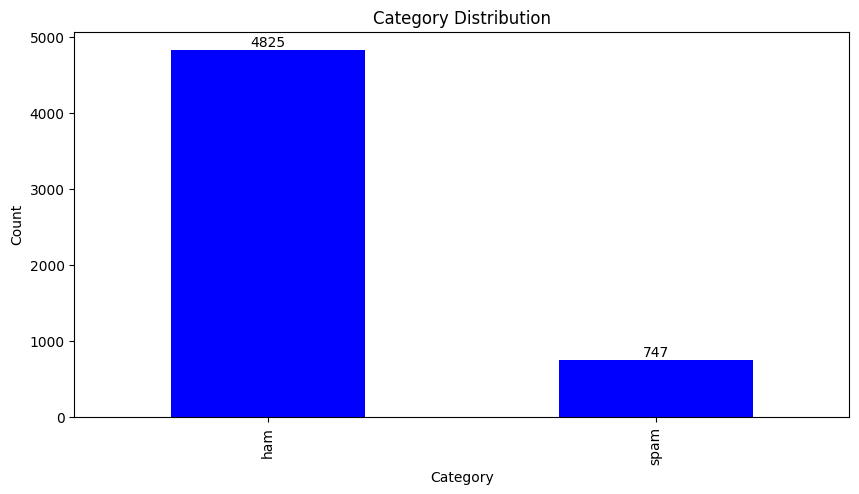

In [18]:
import matplotlib.pyplot as plt

df = df_train
data = df_train['Category'].value_counts()

plt.plot()
data.plot(kind='bar', color='blue', figsize=(10, 5))
for i, v in enumerate(data):
    plt.text(i, v + 10, str(v), ha='center', va='bottom', fontsize=10)
plt.title('Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')

W tym zbiorze danych mamy bardzo nierównomierny rozkład cechy `Category`. Początkowo decydujemy się go zostawić, ponieważ może być to naturalne podejście do badanego problemu, tzn. o wiele więcej wiadomości nie będzie spamem. 

## Preprocesowanie danych

In [19]:
lst = df['Message'][:3].tolist()
for l in lst:
    print(f"{l}\n")

Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Ok lar... Joking wif u oni...

Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's



Możemy zaobserwować, że mogą trafić się wiadomości, które nie zawsze będą pisane poprawnie, a także występować będą nazwy własne jak np. nicki użytkowników czy tym podobne (np. 08452810075over18).

### Sprowadzenie tesktu do małych liter

In [20]:
print(f"== BEFORE LOWER ==\n{df['Message'][:3]}\n")
df['ProcessedMessage'] = df['Message'].str.lower()
print(f"== AFTER LOWER ==\n{df['ProcessedMessage'][:3]}\n")

== BEFORE LOWER ==
0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
Name: Message, dtype: object

== AFTER LOWER ==
0    go until jurong point, crazy.. available only ...
1                        ok lar... joking wif u oni...
2    free entry in 2 a wkly comp to win fa cup fina...
Name: ProcessedMessage, dtype: object



### Usunięcie oznaczeń i linków do stron internetowych

In [41]:
def remove_usernames_and_links(text):
    text = ' '.join([word for word in text.split() if not word.startswith('@')])
    text = ' '.join([word for word in text.split() if not '@' in word])
    text = ' '.join([word for word in text.split() if not word.startswith('http')])
    return text

In [40]:
counter = 0

for i, row in df.iterrows():
    if 'http' in row['ProcessedMessage']:
        print(f"Row {i} contains URL")
        print(f'\t Message: {row["ProcessedMessage"]}')
        counter += 1
        
print(f"== Detected URLs in dataset {counter}/{len(df)} ==\n")

Row 4965 contains URL
	 Message: dear voucher holder next meal us use following link pc  enjoy    dining experiencehttpwwwvouchmecometlpdiningasp
== Detected URLs in dataset 1/5568 ==



In [ ]:
print(f"== BEFORE NICKS AND LINKS ==\n{df['ProcessedMessage'][13:17]}\n")
df['ProcessedMessage'] = df['ProcessedMessage'].apply(remove_usernames_and_links)
print(f"== AFTER NICKS AND LINKS ==\n{df['ProcessedMessage'][13:17]}\n")

== BEFORE LINKS ==
13    i've been searching for the right words to tha...
14                  i have a date on sunday with will!!
15    xxxmobilemovieclub: to use your credit, click ...
16                           oh k...i'm watching here:)
Name: ProcessedMessage, dtype: object

== AFTER LINKS ==
13    i've been searching for the right words to tha...
14                  i have a date on sunday with will!!
15    xxxmobilemovieclub: to use your credit, click ...
16                           oh k...i'm watching here:)
Name: ProcessedMessage, dtype: object



### Usunięcie słów stopu

In [27]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [28]:
from nltk.corpus import stopwords
stop_words = list(stopwords.words('english'))

In [29]:
print(f"== ENGLISH STOPWORDS ==\n{len(stop_words)}\n{stop_words[:10]}\n")

== ENGLISH STOPWORDS ==
198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']



In [30]:
print(f"== BEFORE STOPWORDS ==\n{df['ProcessedMessage'][:3]}\n")
df['ProcessedMessage'] = df['ProcessedMessage'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))
print(f"== AFTER STOPWORDS ==\n{df['ProcessedMessage'][:3]}\n")

== BEFORE STOPWORDS ==
0    go until jurong point, crazy.. available only ...
1                        ok lar... joking wif u oni...
2    free entry in 2 a wkly comp to win fa cup fina...
Name: ProcessedMessage, dtype: object

== AFTER STOPWORDS ==
0    go jurong point, crazy.. available bugis n gre...
1                        ok lar... joking wif u oni...
2    free entry 2 wkly comp win fa cup final tkts 2...
Name: ProcessedMessage, dtype: object



### Usunięcie znaków interpunkcyjnych i cyfr

In [31]:
import re

def remove_numbers(text):
    result = re.sub(r'\d+', '', text)
    return result

def remove_punctuation(text):
    result = re.sub(r'[^\w\s]', '', text)
    return result

In [33]:
print(f"== BEFORE NUMBERS AND PUNCTUATION ==\n{df['ProcessedMessage'][:3]}\n")
df['ProcessedMessage'] = df['ProcessedMessage'].apply(remove_numbers)
df['ProcessedMessage'] = df['ProcessedMessage'].apply(remove_punctuation)
print(f"== AFTER NUMBERS AND PUNCTUATION ==\n{df['ProcessedMessage'][:3]}\n")

== BEFORE NUMBERS AND PUNCTUATION ==
0    go jurong point, crazy.. available bugis n gre...
1                        ok lar... joking wif u oni...
2    free entry 2 wkly comp win fa cup final tkts 2...
Name: ProcessedMessage, dtype: object

== AFTER NUMBERS AND PUNCTUATION ==
0    go jurong point crazy available bugis n great ...
1                              ok lar joking wif u oni
2    free entry  wkly comp win fa cup final tkts st...
Name: ProcessedMessage, dtype: object



### Weryfikacja zbioru po przeczyszczeniu

In [34]:
print(f"Total number of rows in the dataset: {df.shape[0]}")
print(f"Total number of rows with empty tweets: {df[df['ProcessedMessage'] == ''].shape[0]}")
print(f"Total number of rows with empty tweets: {df[df['ProcessedMessage'] == ' '].shape[0]}")
print(f"Total number of rows with empty tweets: {df[df['ProcessedMessage'] == None].shape[0]}")

Total number of rows in the dataset: 5572
Total number of rows with empty tweets: 3
Total number of rows with empty tweets: 1
Total number of rows with empty tweets: 0


Widzimy łącznie 4 rekordy, które podczas czyszczenia zbioru danych ze słów stopu, znaków interpunkcyjnych i linków zostatły puste

In [38]:
idx = df[df['ProcessedMessage'] == ''].index
idx2 = df[df['ProcessedMessage'] == ' '].index
    
print(f"{df['Category'].iloc[idx].value_counts()}")    
print(f"{df['Category'].iloc[idx2].value_counts()}")    

Category
ham    3
Name: count, dtype: int64
Category
ham    1
Name: count, dtype: int64


Rekordy te mają kategorię tylko `ham` stąd dodanie pustych rekordów zaklasyfikowanych jako `ham` może wprowadzać szum.

In [39]:
print(f"== BEFORE DELETE RECORDS ==\t{df.shape[0]}")
df = df[df['ProcessedMessage'] != '']
df = df[df['ProcessedMessage'] != ' ']
print(f"== AFTER DELETE RECORDS ==\t{df.shape[0]}")

== BEFORE DELETE RECORDS ==	5572
== AFTER DELETE RECORDS ==	5568


### TextBlob - Próba wykorzystania narzędzia służącego do poprawienia błędów w słowach

In [57]:
!pip install textblob


[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
from textblob import TextBlob

test_corrected = str(TextBlob(df['ProcessedMessage'][2]).correct())
test_corrected2 = str(TextBlob(df['NLTKProcessed'][2]).correct())
print(test_corrected)
print(df['ProcessedMessage'][2])
print(test_corrected2)

free entry  wily come win a cup final this st may  text a  receive entry questions txt rates apply over
free entry  wkly comp win fa cup final tkts st may  text fa  receive entry questionstd txt ratetcs apply overs
free entry wily come win a cup final this st may text a receive entry questions txt rates apply over


Podejście może poprawić zdania a także zwiększyć ich sens. Przeprowadzimy jeszcze test statystyczny zmian w rekordach. 

In [60]:
df['ProcessedMessageTextBlob'] = df['ProcessedMessage'].apply(lambda x: str(TextBlob(x).correct()))

In [61]:
df['num_changes'] = df.apply(lambda row: sum(1 for o, c in zip(row['ProcessedMessage'].split(), row['ProcessedMessageTextBlob'].split()) if o != c), axis=1)
df['total_words'] = df['ProcessedMessage'].apply(lambda x: len(x.split()))
df['change_ratio'] = df['num_changes'] / df['total_words']

total_words = df['total_words'].sum()
total_changes = df['num_changes'].sum()
percentage_change = (total_changes / total_words) * 100

print(f"Łączna liczba słów: {total_words}")
print(f"Łączna liczba zmian: {total_changes}")
print(f"Procent zmienionych słów: {percentage_change:.2f}%")

Łączna liczba słów: 51073
Łączna liczba zmian: 9954
Procent zmienionych słów: 19.49%


Widzimy, że łączna liczba zmienionych/poprawionych słów to 9954/51073 co daje blisko 20% zmian. Jest to optymalna zmiana, która może pozytywnie wpłynąć na dalszą analizę i same przewidywania.

In [ ]:
top_changed = df.sort_values(by='num_changes', ascending=False).head(10)
print(top_changed[['text', 'corrected', 'num_changes']])

### Lematyzacja 

Jest to proces sprowadzania słów do ich podstawowych form. Do tego celu możemy wykorzystać dwie biblioteki - NLTK oraz SpaCy. 

In [42]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [43]:
!python -m spacy download en_core_web_sm
import spacy
nlp = spacy.load('en_core_web_sm')

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---- ----------------------------------- 1.6/12.8 MB 16.8 MB/s eta 0:00:01
     ----------------------------------- --- 11.8/12.8 MB 40.9 MB/s eta 0:00:01
     --------------------------------------- 12.8/12.8 MB 36.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
print(f"== BEFORE LEMMATIZATION ==\n{df['ProcessedMessage'][:3]}\n")
df['NLTKProcessed'] = df['ProcessedMessage'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]))
df['SpacyProcessed'] = df['ProcessedMessage'].apply(lambda x: ' '.join([token.lemma_ for token in nlp(x)]))
print(f"== AFTER LEMMATIZATION (NLTK)==\n{df['NLTKProcessed'][:3]}\n")
print(f"== AFTER LEMMATIZATION (SPACY)==\n{df['SpacyProcessed'][:3]}\n")

== BEFORE LEMMATIZATION ==
0    go jurong point crazy available bugis n great ...
1                              ok lar joking wif u oni
2    free entry  wkly comp win fa cup final tkts st...
Name: ProcessedMessage, dtype: object

== AFTER LEMMATIZATION (NLTK)==
0    go jurong point crazy available bugis n great ...
1                              ok lar joking wif u oni
2    free entry wkly comp win fa cup final tkts st ...
Name: NLTKProcessed, dtype: object

== AFTER LEMMATIZATION (SPACY)==
0    go jurong point crazy available bugis n great ...
1                              ok lar joking wif u oni
2    free entry   wkly comp win fa cup final tkts s...
Name: SpacyProcessed, dtype: object



Możemy także sprawdzić jak różnią się od siebie oba zbiory. 

In [45]:
df.columns

Index(['Category', 'Message', 'ProcessedMessage', 'NLTKProcessed',
       'SpacyProcessed'],
      dtype='object')

In [46]:
differences = df[df['NLTKProcessed'] != df['SpacyProcessed']]
print(f"== DIFFERENT RECORDS ==\nLiczba różniących się wierszy: {len(differences)}, wszystkich jest: {len(df)}\n")

== DIFFERENT RECORDS ==
Liczba różniących się wierszy: 3791, wszystkich jest: 5568



In [47]:
def compare_words(nltk_text, spacy_text):
    nltk_words = set(nltk_text.split())
    spacy_words = set(spacy_text.split())
    return {
        'only_in_nltk': nltk_words - spacy_words,
        'only_in_spacy': spacy_words - nltk_words
    }

nltk_words = set(' '.join(df['NLTKProcessed']).split())
spacy_words = set(' '.join(df['SpacyProcessed']).split())

only_in_nltk = nltk_words - spacy_words
only_in_spacy = spacy_words - nltk_words

total_unique_words = len(nltk_words.union(spacy_words))
different_words = len(only_in_nltk) + len(only_in_spacy)
percentage_difference = (different_words / total_unique_words) * 100

print(f"Liczba unikalnych słów w NLTK: {len(nltk_words)}")
print(f"Liczba unikalnych słów w SpaCy: {len(spacy_words)}")
print(f"Liczba słów różniących się między NLTK i SpaCy: {different_words}")
print(f"Procent różnic na poziomie słów: {percentage_difference:.2f}%")

Liczba unikalnych słów w NLTK: 8077
Liczba unikalnych słów w SpaCy: 7597
Liczba słów różniących się między NLTK i SpaCy: 1490
Procent różnic na poziomie słów: 17.36%


Widzimy, że na zbiorze niemalże 5572 rekordów oba lematyzatory różnią się od siebie w sposobie sprowadzania słów do podstawowej postaci. Stąd też wytrenowane modele będziemy weryfikować uwzględniając, który lematyzator został użyty.

W przypadku analizy zbioru Corona widzieliśmy, że ten błąd (różnice słów na tych samych miejscach w rekordach) była większa o około 8 punktów procentowych).

### Stematyzacja

Stemming to proces obcinania końcówek słów sprowadzając je do rdzenia. Nie bierze przy tym pod uwagę, czy takie słowo istnieje czy też nie. Tym właśnie różni się od lematyzacji, która sprowadza do podstawowej formy, ale to słowo jest w słowniku. 

In [48]:
from nltk.stem import PorterStemmer 
stemmer = PorterStemmer()

In [49]:
print(f"== BEFORE STEMMING ==\n{df['ProcessedMessage'][:3]}\n")
df['Stemmed'] = df['ProcessedMessage'].apply(lambda x: ' '.join([stemmer.stem(word) for word in x.split()]))
print(f"== AFTER STEMMING ==\n{df['Stemmed'][:3]}\n")

== BEFORE STEMMING ==
0    go jurong point crazy available bugis n great ...
1                              ok lar joking wif u oni
2    free entry  wkly comp win fa cup final tkts st...
Name: ProcessedMessage, dtype: object

== AFTER STEMMING ==
0    go jurong point crazi avail bugi n great world...
1                                ok lar joke wif u oni
2    free entri wkli comp win fa cup final tkt st m...
Name: Stemmed, dtype: object



## Modele ML

### Przygotowanie danych do modeli

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import time

In [ ]:
# accuracy, precision, recall, f1-score
eval_metrics = {
    'NLTK': {
        'Naive Bayes': {},
        'SVM': {},
        'Random Forest': {},
        'Logistic Regression': {},
        'BERT': {}
    }, 
    'SpaCy': {
        'Naive Bayes': {},
        'SVM': {},
        'Random Forest': {},
        'Logistic Regression': {},
        'BERT': {}
    },
    'Stemmed': {
        'Naive Bayes': {},
        'SVM': {},
        'Random Forest': {},
        'Logistic Regression': {},
        'BERT': {}
    },
    'Processed': {
        'Naive Bayes': {},
        'SVM': {},
        'Random Forest': {},
        'Logistic Regression': {},
        'BERT': {}
    },
    'Original': {
        'Naive Bayes': {},
        'SVM': {},
        'Random Forest': {},
        'Logistic Regression': {},
        'BERT': {}
    }
}